In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay

In [2]:
column_names = [
    "id", "diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean",
    "compactness_mean", "concavity_mean", "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se", "smoothness_se",
    "compactness_se", "concavity_se", "concave_points_se", "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst", "smoothness_worst",
    "compactness_worst", "concavity_worst", "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

In [3]:
df = pd.read_csv("dataset/wdbc.data", header=None, names=column_names)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

In [5]:
X = df.drop(columns=["id", "diagnosis"])
y = df["diagnosis"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (569, 30)
Target Shape: (569,)


In [6]:
print(y.value_counts())

diagnosis
0    357
1    212
Name: count, dtype: int64


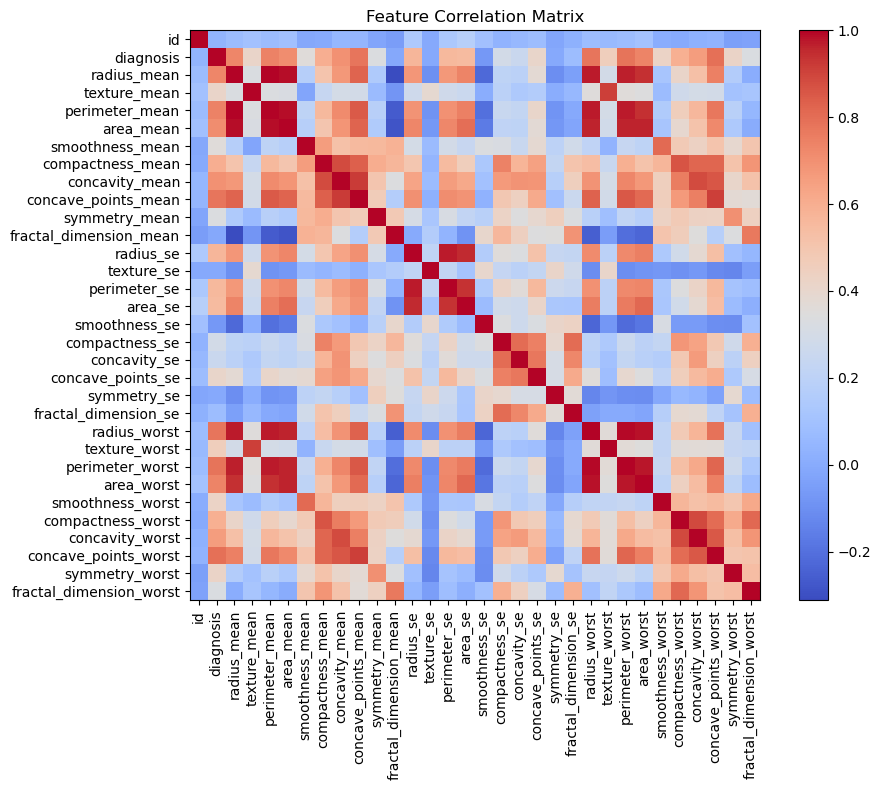

In [7]:
correlation_matrix = df.corr()

plt.figure(figsize=(10,8))
plt.imshow(correlation_matrix, cmap='coolwarm')

# Add colorbar
plt.colorbar()

# Add axis labels (column names)
plt.xticks(
    ticks=range(len(correlation_matrix.columns)),
    labels=correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    ticks=range(len(correlation_matrix.columns)),
    labels=correlation_matrix.columns
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()

plt.savefig("images/correlation.png", dpi=300)
plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y 
)

Accuracy: 0.9736842105263158

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


Confusion Matrix:
 [[72  0]
 [ 3 39]]


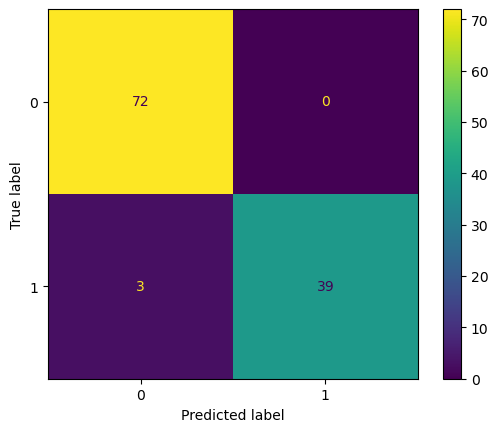

In [10]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Base estimator
base_model = DecisionTreeClassifier()

# Bagging classifier
bagging_model = BaggingClassifier(
    estimator=base_model,     # base learner
    n_estimators=50,          # number of trees
    max_samples=0.8,          # samples per estimator
    bootstrap=True,
    random_state=42
)

# Train the model
bagging_model.fit(X_train, y_train)

# Predictions
y_pred = bagging_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.savefig("images/conf_bagging.png", dpi=300)


C:\Users\HP\anaconda3\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost Accuracy: 0.9736842105263158

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


Confusion Matrix:
 [[72  0]
 [ 3 39]]


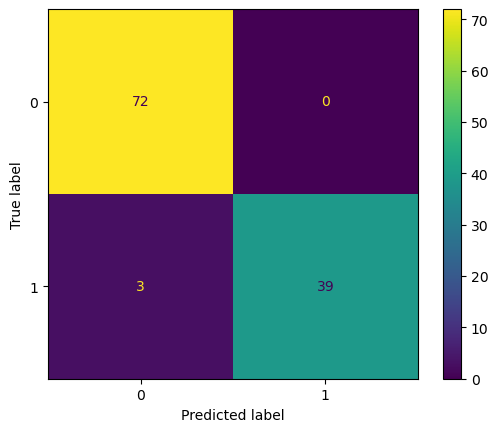

In [11]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Base estimator (weak learner)
base_estimator = DecisionTreeClassifier(max_depth=1)

# AdaBoost model
ada_model = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

# Train
ada_model.fit(X_train, y_train)

# Predict
y_pred_ada = ada_model.predict(X_test)

# Evaluation
print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print("\nClassification Report:\n", classification_report(y_test, y_pred_ada))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_ada))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.savefig("images/conf_adaboost.png", dpi=300)

Gradient Boosting Accuracy: 0.9649122807017544

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114


Confusion Matrix:
 [[72  0]
 [ 4 38]]


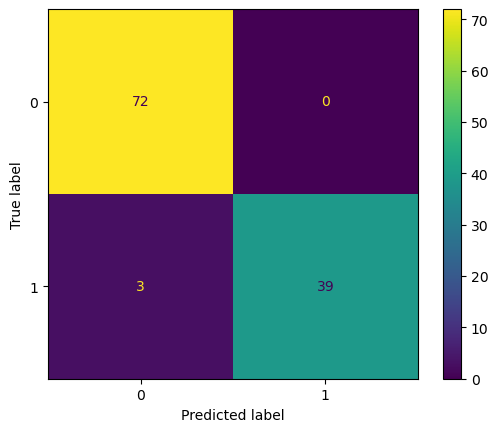

In [12]:
from sklearn.ensemble import GradientBoostingClassifier

# Gradient Boosting model
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train
gb_model.fit(X_train, y_train)

# Predict
y_pred_gb = gb_model.predict(X_test)

# Evaluation
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.savefig("images/conf_gradboost.png", dpi=300)

Stacking Accuracy: 0.9385964912280702

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.99      0.95        72
           1       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114


Confusion Matrix:
 [[71  1]
 [ 6 36]]


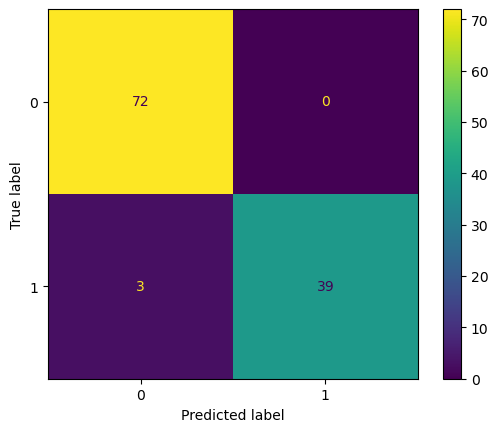

In [13]:
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Base models
base_models = [
    ('dt', DecisionTreeClassifier()),
    ('knn', KNeighborsClassifier()),
    ('svm', SVC(probability=True))
]

# Meta model
meta_model = LogisticRegression()

# Stacking classifier
stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model
)

# Train
stack_model.fit(X_train, y_train)

# Predict
y_pred_stack = stack_model.predict(X_test)

# Evaluation
print("Stacking Accuracy:", accuracy_score(y_test, y_pred_stack))
print("\nClassification Report:\n", classification_report(y_test, y_pred_stack))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_stack))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.savefig("images/conf_stacking.png", dpi=300)

In [14]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Model
bag_model = BaggingClassifier(estimator=DecisionTreeClassifier(), random_state=42)

# Search space
bagging_params = {
    'n_estimators': [10, 50, 100],
    'max_samples': [0.5, 0.7, 1.0],
    'max_features': [0.5, 0.7, 1.0],
    'bootstrap': [True, False]
}

# Grid Search
bag_grid = GridSearchCV(
    estimator=bag_model,
    param_grid=bagging_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

bag_grid.fit(X_train, y_train)

print("Best Bagging Parameters:", bag_grid.best_params_)
print("Best CV Score:", bag_grid.best_score_)

Best Bagging Parameters: {'bootstrap': True, 'max_features': 0.5, 'max_samples': 0.7, 'n_estimators': 50}
Best CV Score: 0.9692307692307693


In [15]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV

# Model
ada_model = AdaBoostClassifier(random_state=42)

# Search space
adaboost_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0]
}

# Grid Search
ada_grid = GridSearchCV(
    estimator=ada_model,
    param_grid=adaboost_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

ada_grid.fit(X_train, y_train)

print("Best AdaBoost Parameters:", ada_grid.best_params_)
print("Best CV Score:", ada_grid.best_score_)

C:\Users\HP\anaconda3\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Best AdaBoost Parameters: {'learning_rate': 1.0, 'n_estimators': 100}
Best CV Score: 0.9626373626373628


In [16]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

# Model
gb_model = GradientBoostingClassifier(random_state=42)

# Search space
gradient_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

# Grid Search
gb_grid = GridSearchCV(
    estimator=gb_model,
    param_grid=gradient_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print("Best Gradient Boosting Parameters:", gb_grid.best_params_)
print("Best CV Score:", gb_grid.best_score_)

Best Gradient Boosting Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best CV Score: 0.9670329670329672


In [17]:
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Base models
base_models = [
    ('dt', DecisionTreeClassifier()),
    ('knn', KNeighborsClassifier())
]

# Stacking model
stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression()
)

# Search space (meta learner tuning)
stack_params = {
    'final_estimator__C': [0.01, 0.1, 1, 10],
    'final_estimator__solver': ['lbfgs', 'liblinear']
}

# Grid Search
stack_grid = GridSearchCV(
    estimator=stack_model,
    param_grid=stack_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

stack_grid.fit(X_train, y_train)

print("Best Stacking Parameters:", stack_grid.best_params_)
print("Best CV Score:", stack_grid.best_score_)

Best Stacking Parameters: {'final_estimator__C': 10, 'final_estimator__solver': 'liblinear'}
Best CV Score: 0.9384615384615385


In [18]:
import pandas as pd

bag_results = pd.DataFrame(bag_grid.cv_results_)

bag_sorted = bag_results.sort_values(by='mean_test_score', ascending=False)

print(bag_sorted[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']])

                                               params  mean_test_score  \
4   {'bootstrap': True, 'max_features': 0.5, 'max_...         0.969231   
7   {'bootstrap': True, 'max_features': 0.5, 'max_...         0.969231   
8   {'bootstrap': True, 'max_features': 0.5, 'max_...         0.969231   
17  {'bootstrap': True, 'max_features': 0.7, 'max_...         0.969231   
2   {'bootstrap': True, 'max_features': 0.5, 'max_...         0.964835   
13  {'bootstrap': True, 'max_features': 0.7, 'max_...         0.964835   
16  {'bootstrap': True, 'max_features': 0.7, 'max_...         0.962637   
50  {'bootstrap': False, 'max_features': 1.0, 'max...         0.962637   
9   {'bootstrap': True, 'max_features': 0.7, 'max_...         0.962637   
35  {'bootstrap': False, 'max_features': 0.5, 'max...         0.962637   
11  {'bootstrap': True, 'max_features': 0.7, 'max_...         0.962637   
0   {'bootstrap': True, 'max_features': 0.5, 'max_...         0.960440   
1   {'bootstrap': True, 'max_features'

In [19]:
ada_results = pd.DataFrame(ada_grid.cv_results_)

ada_sorted = ada_results.sort_values(by='mean_test_score', ascending=False)

print(ada_sorted[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']])

                                         params  mean_test_score  \
7   {'learning_rate': 1.0, 'n_estimators': 100}         0.962637   
8   {'learning_rate': 1.0, 'n_estimators': 200}         0.962637   
4   {'learning_rate': 0.1, 'n_estimators': 100}         0.956044   
5   {'learning_rate': 0.1, 'n_estimators': 200}         0.956044   
3    {'learning_rate': 0.1, 'n_estimators': 50}         0.949451   
6    {'learning_rate': 1.0, 'n_estimators': 50}         0.949451   
2  {'learning_rate': 0.01, 'n_estimators': 200}         0.940659   
1  {'learning_rate': 0.01, 'n_estimators': 100}         0.931868   
0   {'learning_rate': 0.01, 'n_estimators': 50}         0.929670   

   std_test_score  rank_test_score  
7        0.017855                1  
8        0.029974                1  
4        0.031849                3  
5        0.036776                3  
3        0.038446                5  
6        0.031544                6  
2        0.037812                7  
1        0.038320      

In [20]:
gb_results = pd.DataFrame(gb_grid.cv_results_)

gb_sorted = gb_results.sort_values(by='mean_test_score', ascending=False)

print(gb_sorted[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']])

                                               params  mean_test_score  \
14  {'learning_rate': 0.1, 'max_depth': 5, 'n_esti...         0.967033   
10  {'learning_rate': 0.1, 'max_depth': 3, 'n_esti...         0.964835   
12  {'learning_rate': 0.1, 'max_depth': 5, 'n_esti...         0.962637   
8   {'learning_rate': 0.1, 'max_depth': 3, 'n_esti...         0.958242   
9   {'learning_rate': 0.1, 'max_depth': 3, 'n_esti...         0.953846   
11  {'learning_rate': 0.1, 'max_depth': 3, 'n_esti...         0.953846   
2   {'learning_rate': 0.01, 'max_depth': 3, 'n_est...         0.951648   
6   {'learning_rate': 0.01, 'max_depth': 5, 'n_est...         0.951648   
3   {'learning_rate': 0.01, 'max_depth': 3, 'n_est...         0.942857   
0   {'learning_rate': 0.01, 'max_depth': 3, 'n_est...         0.940659   
4   {'learning_rate': 0.01, 'max_depth': 5, 'n_est...         0.940659   
7   {'learning_rate': 0.01, 'max_depth': 5, 'n_est...         0.934066   
5   {'learning_rate': 0.01, 'max_depth

In [21]:
stack_results = pd.DataFrame(stack_grid.cv_results_)

stack_sorted = stack_results.sort_values(by='mean_test_score', ascending=False)

stack_sorted[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
print(stack_sorted['params'])

7    {'final_estimator__C': 10, 'final_estimator__s...
2    {'final_estimator__C': 0.1, 'final_estimator__...
5    {'final_estimator__C': 1, 'final_estimator__so...
1    {'final_estimator__C': 0.01, 'final_estimator_...
6    {'final_estimator__C': 10, 'final_estimator__s...
4    {'final_estimator__C': 1, 'final_estimator__so...
3    {'final_estimator__C': 0.1, 'final_estimator__...
0    {'final_estimator__C': 0.01, 'final_estimator_...
Name: params, dtype: object


In [22]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability predictions
y_prob = ada_model.predict_proba(X_test)[:,1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC
auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AdaBoost (AUC = {auc_score:.3f})")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Base Model")
plt.legend()
plt.savefig("images/correlation.png", dpi=300)

plt.show()

NotFittedError: This AdaBoostClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [23]:
best_ada = ada_grid.best_estimator_

y_prob_best = best_ada.predict_proba(X_test)[:,1]

fpr_best, tpr_best, _ = roc_curve(y_test, y_prob_best)

auc_best = roc_auc_score(y_test, y_prob_best)

print("Best Tuned AUC:", auc_best)

Best Tuned AUC: 0.9910714285714285


In [24]:
plt.figure()

plt.plot(fpr, tpr, label=f"Base AdaBoost (AUC = {auc_score:.3f})")
plt.plot(fpr_best, tpr_best, label=f"Tuned AdaBoost (AUC = {auc_best:.3f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

NameError: name 'fpr' is not defined

<Figure size 640x480 with 0 Axes>

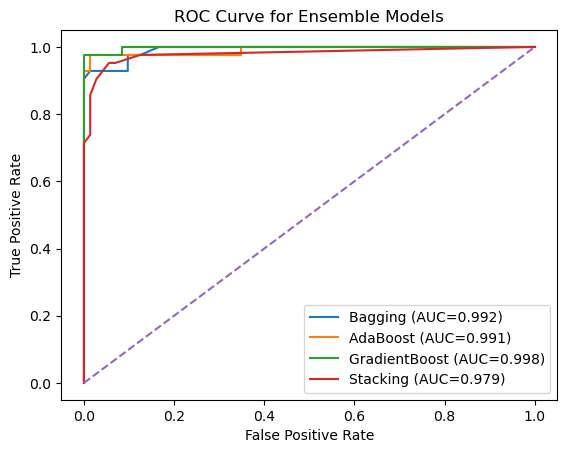

In [25]:
models = {
    "Bagging": bag_grid.best_estimator_,
    "AdaBoost": ada_grid.best_estimator_,
    "GradientBoost": gb_grid.best_estimator_,
    "Stacking": stack_grid.best_estimator_
}

plt.figure()

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Ensemble Models")
plt.legend()
plt.savefig("images/roc_all.png", dpi=300)

plt.show()